# 12-1 Métricas de Evaluación para Regresión Logística

**Curso:** Modelos de Análisis Estadístico — Universidad de los Andes  
**Profesora:** Alejandra Tabares

---

## Introducción

Una vez ajustado un modelo de regresión logística, es necesario evaluar qué tan bien clasifica nuevas observaciones. A diferencia de la regresión lineal, donde podemos apoyarnos en $R^2$ o el RMSE, los modelos de clasificación requieren un conjunto de herramientas diferente.

El punto de partida para evaluar cualquier clasificador binario es la **matriz de confusión**, que tabula las predicciones del modelo frente a las etiquetas de clase verdaderas en cuatro categorías:

| | Predicho Positivo | Predicho Negativo |
|---|---|---|
| **Real Positivo** | Verdadero Positivo (TP) | Falso Negativo (FN) |
| **Real Negativo** | Falso Positivo (FP) | Verdadero Negativo (TN) |

- **Verdadero Positivo (TP):** el modelo predijo correctamente la clase positiva.
- **Verdadero Negativo (TN):** el modelo predijo correctamente la clase negativa.
- **Falso Positivo (FP):** el modelo predijo positivo, pero la etiqueta verdadera es negativa (error de Tipo I).
- **Falso Negativo (FN):** el modelo predijo negativo, pero la etiqueta verdadera es positiva (error de Tipo II).

El umbral de clasificación por defecto en `sklearn` es **0.5**: si $\hat{p} \geq 0.5$, predice la clase 1; de lo contrario predice la clase 0.

In [1]:
# ── Importaciones ──────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    ConfusionMatrixDisplay,
)

np.random.seed(42)
print("Bibliotecas cargadas exitosamente.")

Bibliotecas cargadas exitosamente.


## 1. Generación de Datos Sintéticos y Ajuste del Modelo de Regresión Logística

Simulamos un conjunto de datos de clasificación binaria con 1,000 observaciones y 5 características informativas. El conjunto de datos se divide en un conjunto de entrenamiento (70 %) y un conjunto de prueba (30 %).

In [2]:
# ── Simular datos ─────────────────────────────────────────────────────
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=5,
    n_redundant=2,
    n_classes=2,
    class_sep=0.8,
    random_state=42,
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"Muestras de entrenamiento : {X_train.shape[0]}")
print(f"Muestras de prueba        : {X_test.shape[0]}")
print(f"Balance de clases (prueba) — 0: {(y_test==0).sum()}, 1: {(y_test==1).sum()}")

Muestras de entrenamiento : 700
Muestras de prueba        : 300
Balance de clases (prueba) — 0: 149, 1: 151


In [3]:
# ── Ajustar regresión logística (sin regularización — C muy grande) ────────────────
model = LogisticRegression(C=1e6, max_iter=1000, random_state=42)
model.fit(X_train, y_train)

y_pred  = model.predict(X_test)           # predicciones de clase dura
y_prob  = model.predict_proba(X_test)[:, 1]  # probabilidades predichas para la clase 1

print("Modelo ajustado.")
print(f"Primeras 10 probabilidades predichas: {np.round(y_prob[:10], 3)}")

Modelo ajustado.
Primeras 10 probabilidades predichas: [0.449 0.886 0.962 0.668 0.313 0.495 0.388 0.425 0.483 0.118]


## 2. Matriz de Confusión

La matriz de confusión proporciona una imagen completa del desempeño del clasificador en cada clase. Calculemos la matriz y visualicémosla como un mapa de calor.

In [4]:
# ── Calcular la matriz de confusión ──────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
print("Matriz de Confusión:")
print(cm)

tn, fp, fn, tp = cm.ravel()
print(f"\nTN={tn}  FP={fp}  FN={fn}  TP={tp}")

Matriz de Confusión:
[[120  29]
 [ 39 112]]

TN=120  FP=29  FN=39  TP=112


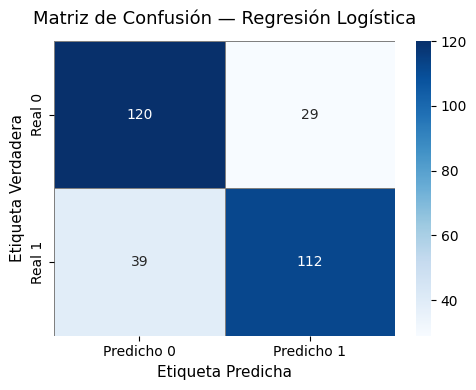

In [5]:
# ── Visualizar la matriz de confusión ────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicho 0", "Predicho 1"],
    yticklabels=["Real 0", "Real 1"],
    ax=ax,
    linewidths=0.5,
    linecolor="gray",
)

ax.set_title("Matriz de Confusión — Regresión Logística", fontsize=13, pad=12)
ax.set_ylabel("Etiqueta Verdadera", fontsize=11)
ax.set_xlabel("Etiqueta Predicha", fontsize=11)
plt.tight_layout()
plt.show()

## 3. Métricas de Clasificación: Exactitud, Precisión, Exhaustividad, F1-Score

A partir de las cuatro celdas de la matriz de confusión podemos derivar las siguientes métricas escalares:

$$\text{Exactitud} = \frac{TP + TN}{TP + TN + FP + FN}$$

$$\text{Precisi\u00f3n} = \frac{TP}{TP + FP}$$

$$\text{Exhaustividad (Sensibilidad)} = \frac{TP}{TP + FN}$$

$$\text{Especificidad} = \frac{TN}{TN + FP}$$

$$\text{F1-Score} = 2 \cdot \frac{\text{Precisi\u00f3n} \times \text{Exhaustividad}}{\text{Precisi\u00f3n} + \text{Exhaustividad}}$$

**Compromiso clave:** La Precisión y la Exhaustividad suelen moverse en direcciones opuestas. En diagnóstico médico típicamente se prioriza la **Exhaustividad** (evitar pasar por alto pacientes enfermos), mientras que en filtrado de spam se puede priorizar la **Precisión** (evitar marcar correos legítimos como spam). El F1-Score proporciona un resumen equilibrado único cuando ambos tipos de error tienen costos similares.

> **Nota:** La exactitud puede ser engañosa cuando las clases están desbalanceadas. Por ejemplo, si el 95 % de las observaciones pertenecen a la clase 0, un modelo que siempre predice 0 alcanza el 95 % de exactitud siendo completamente inútil para detectar la clase 1.

In [6]:
# ── Calcular métricas manualmente a partir de la matriz de confusión ────────
accuracy    = (tp + tn) / (tp + tn + fp + fn)
precision   = tp / (tp + fp)
recall      = tp / (tp + fn)
specificity = tn / (tn + fp)
f1          = 2 * precision * recall / (precision + recall)

print("Cálculo manual a partir de la matriz de confusión:")
print(f"  Exactitud    : {accuracy:.4f}")
print(f"  Precisión    : {precision:.4f}")
print(f"  Exhaustividad: {recall:.4f}")
print(f"  Especificidad: {specificity:.4f}")
print(f"  F1-Score     : {f1:.4f}")

Cálculo manual a partir de la matriz de confusión:
  Exactitud    : 0.7733
  Precisión    : 0.7943
  Exhaustividad: 0.7417
  Especificidad: 0.8054
  F1-Score     : 0.7671


In [7]:
# ── Reporte de clasificación de sklearn ───────────────────────────────
print("Reporte de Clasificación (sklearn):")
print(classification_report(y_test, y_pred, target_names=["Clase 0", "Clase 1"]))

Reporte de Clasificación (sklearn):
              precision    recall  f1-score   support

     Clase 0       0.75      0.81      0.78       149
     Clase 1       0.79      0.74      0.77       151

    accuracy                           0.77       300
   macro avg       0.77      0.77      0.77       300
weighted avg       0.77      0.77      0.77       300



El `classification_report` proporciona precisión, exhaustividad y F1-score para **cada clase**, así como promedios macro y ponderado.

- **Promedio macro**: media no ponderada de las métricas por clase — trata todas las clases por igual independientemente de su frecuencia.
- **Promedio ponderado**: media de las métricas por clase ponderada por el número de instancias verdaderas por clase — tiene en cuenta el desbalance de clases.

## 4. Curva ROC y AUC

Las métricas anteriores dependen del umbral de clasificación elegido (por defecto 0.5). La **curva Característica Operativa del Receptor (ROC)** es una herramienta de diagnóstico independiente del umbral que grafica:

- **Tasa de Verdaderos Positivos (Sensibilidad / Exhaustividad)** en el eje y: $TPR = \frac{TP}{TP + FN}$
- **Tasa de Falsos Positivos (1 − Especificidad)** en el eje x: $FPR = \frac{FP}{FP + TN}$

a medida que el umbral varía de 1 a 0.

El **Área Bajo la Curva (AUC)** resume la curva ROC con un único número:
- AUC = 0.5 → clasificador aleatorio (línea diagonal)
- AUC = 1.0 → clasificador perfecto (esquina superior izquierda)
- AUC > 0.7 se considera generalmente aceptable; > 0.8 es bueno; > 0.9 es excelente

Interpretación probabilística: el AUC es la probabilidad de que el modelo asigne una **puntuación más alta a un ejemplo positivo elegido al azar que a un ejemplo negativo elegido al azar**.

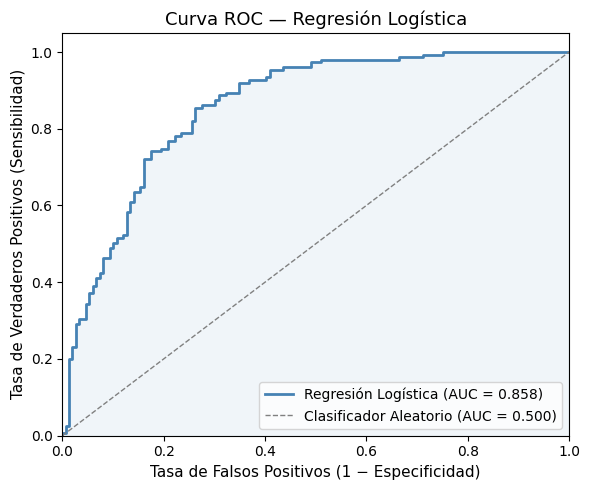

AUC = 0.8583


In [8]:
# ── Curva ROC para el modelo principal ────────────────────────────────
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(6, 5))

ax.plot(fpr, tpr, color="steelblue", lw=2, label=f"Regresión Logística (AUC = {auc_score:.3f})")
ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Clasificador Aleatorio (AUC = 0.500)")

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("Tasa de Falsos Positivos (1 − Especificidad)", fontsize=11)
ax.set_ylabel("Tasa de Verdaderos Positivos (Sensibilidad)", fontsize=11)
ax.set_title("Curva ROC — Regresión Logística", fontsize=13)
ax.legend(loc="lower right", fontsize=10)
ax.fill_between(fpr, tpr, alpha=0.08, color="steelblue")

plt.tight_layout()
plt.show()

print(f"AUC = {auc_score:.4f}")

## 5. Comparación de Dos Modelos en el Gráfico ROC

Un uso común de la curva ROC es comparar modelos en competencia. Ahora ajustamos un segundo modelo **con fuerte regularización L2** (C pequeño) y superponemos ambas curvas ROC.

/Users/a.tabaresp/venv_datascience/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


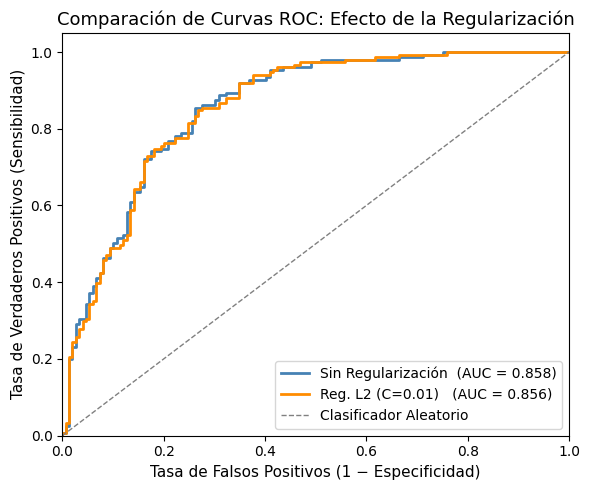

Modelo 1 (sin reg.)  AUC = 0.8583
Modelo 2 (reg. L2)   AUC = 0.8562
Diferencia en AUC    : +0.0021


In [9]:
# ── Modelo 1: sin regularización (C=1e6) — ya ajustado como `model` ─────────
# ── Modelo 2: fuerte regularización L2 (C=0.01) ──────────────────────
model_reg = LogisticRegression(C=0.01, penalty="l2", max_iter=1000, random_state=42)
model_reg.fit(X_train, y_train)
y_prob_reg = model_reg.predict_proba(X_test)[:, 1]

fpr2, tpr2, _ = roc_curve(y_test, y_prob_reg)
auc2 = roc_auc_score(y_test, y_prob_reg)

# ── Graficar ambas curvas ROC ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))

ax.plot(fpr,  tpr,  color="steelblue",   lw=2, label=f"Sin Regularización  (AUC = {auc_score:.3f})")
ax.plot(fpr2, tpr2, color="darkorange",  lw=2, label=f"Reg. L2 (C=0.01)   (AUC = {auc2:.3f})")
ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Clasificador Aleatorio")

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("Tasa de Falsos Positivos (1 − Especificidad)", fontsize=11)
ax.set_ylabel("Tasa de Verdaderos Positivos (Sensibilidad)", fontsize=11)
ax.set_title("Comparación de Curvas ROC: Efecto de la Regularización", fontsize=13)
ax.legend(loc="lower right", fontsize=10)

plt.tight_layout()
plt.show()

print(f"Modelo 1 (sin reg.)  AUC = {auc_score:.4f}")
print(f"Modelo 2 (reg. L2)   AUC = {auc2:.4f}")
print(f"Diferencia en AUC    : {auc_score - auc2:+.4f}")

## 6. Tabla de Resumen

La celda siguiente reúne todas las métricas calculadas en una única tabla de resumen para facilitar la comparación.

In [10]:
# ── Calcular métricas para ambos modelos ──────────────────────────────
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_reg = model_reg.predict(X_test)

def metric_row(name, y_true, y_pred_labels, y_pred_proba):
    return {
        "Model"      : name,
        "Accuracy"   : accuracy_score(y_true, y_pred_labels),
        "Precision"  : precision_score(y_true, y_pred_labels),
        "Recall"     : recall_score(y_true, y_pred_labels),
        "F1-Score"   : f1_score(y_true, y_pred_labels),
        "AUC"        : roc_auc_score(y_true, y_pred_proba),
    }

summary = pd.DataFrame([
    metric_row("Logística (sin reg.)", y_test, y_pred,     y_prob),
    metric_row("Logística (reg. L2)", y_test, y_pred_reg, y_prob_reg),
])

summary = summary.set_index("Model")
print(summary.round(4).to_string())

                      Accuracy  Precision  Recall  F1-Score     AUC
Model                                                              
Logística (sin reg.)    0.7733     0.7943  0.7417    0.7671  0.8583
Logística (reg. L2)     0.7767     0.7917  0.7550    0.7729  0.8562


## Conclusiones Clave

1. La **matriz de confusión** es la base de todas las métricas de clasificación. Siempre inspecciónela primero.
2. La **exactitud** es intuitiva pero poco confiable cuando las clases están desbalanceadas.
3. La **precisión** y la **exhaustividad** capturan diferentes tipos de errores; el equilibrio correcto depende del costo de cada error en el dominio de aplicación.
4. El **F1-Score** combina precisión y exhaustividad en una sola métrica mediante la media armónica.
5. La **curva ROC** y el **AUC** evalúan la capacidad discriminativa del modelo a través de todos los umbrales posibles, haciéndolos más robustos para la comparación de modelos.
6. Un AUC más alto no siempre se traduce en mejores predicciones en el umbral operacional — siempre examine la matriz de confusión completa en el umbral que planea implementar.